✔ Wykres zapisany


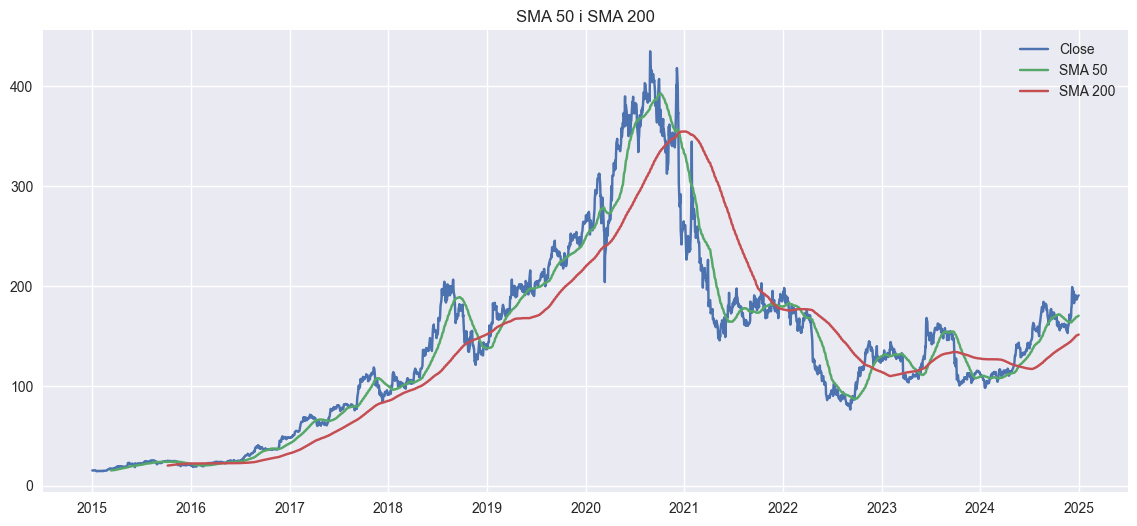

✔ Wykres zapisany


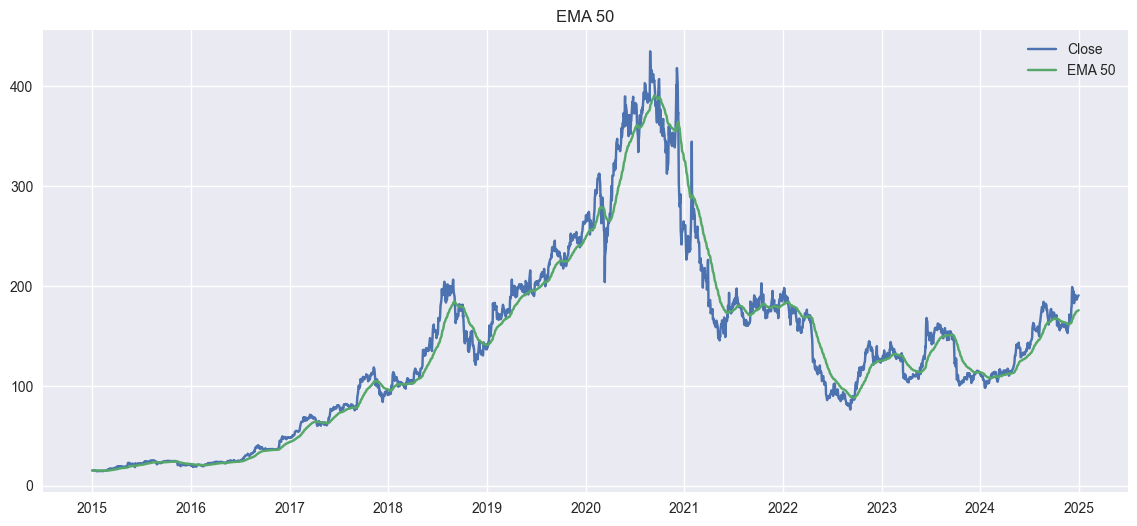

✔ Wykres zapisany


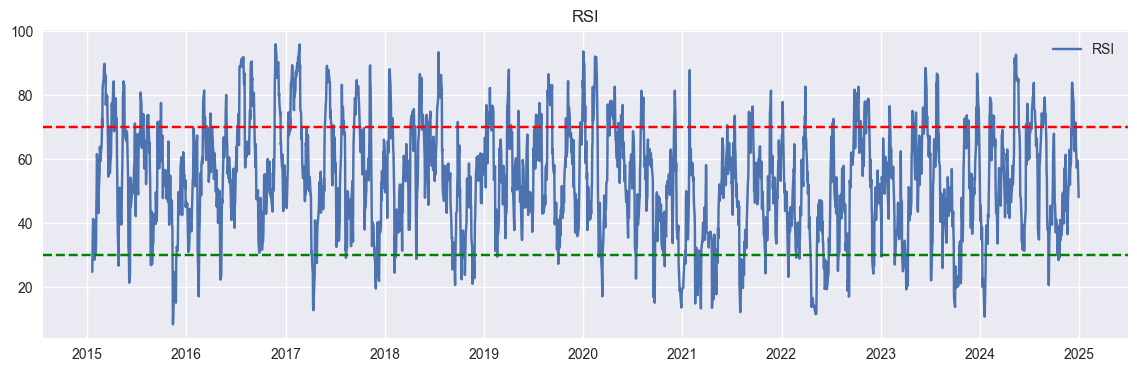

✔ Wykres zapisany


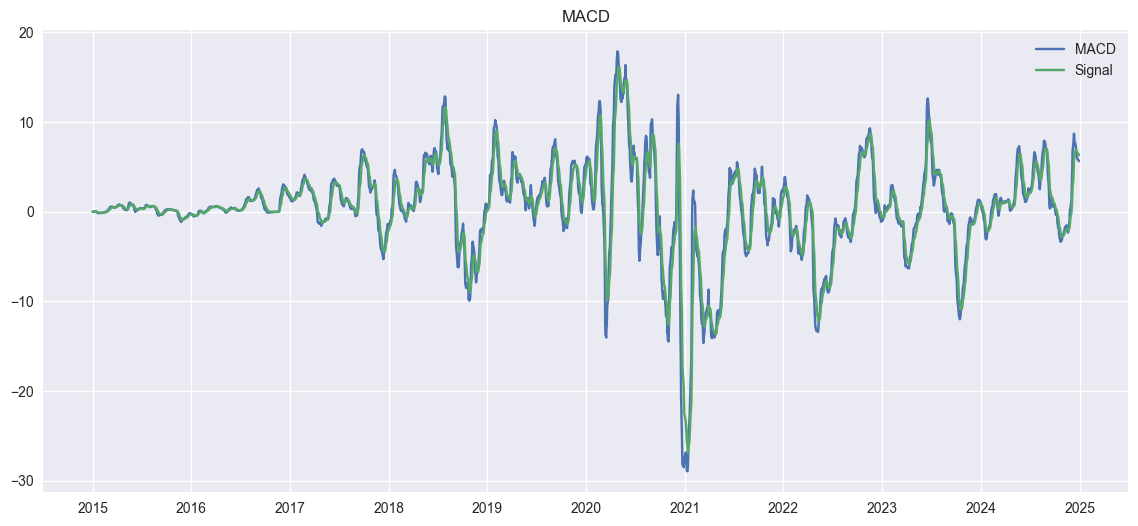

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Simple Moving Average
df["SMA_50"] = df["Close"].rolling(window=50).mean()
df["SMA_200"] = df["Close"].rolling(window=200).mean()

plt.figure(figsize=(14,6))
plt.plot(df["Close"], label="Close")
plt.plot(df["SMA_50"], label="SMA 50")
plt.plot(df["SMA_200"], label="SMA 200")
plt.title("SMA 50 i SMA 200")
plt.grid(True)
plt.legend()
save_plot("cdprojekt_sma.png")
plt.show()

# Exponential Moving Average
df["EMA_50"] = df["Close"].ewm(span=50, adjust=False).mean()

plt.figure(figsize=(14,6))
plt.plot(df["Close"], label="Close")
plt.plot(df["EMA_50"], label="EMA 50")
plt.title("EMA 50")
plt.grid(True)
plt.legend()
save_plot("cdprojekt_ema.png")
plt.show()

# RSI – Relative Strength Index
delta = df["Close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df["RSI"] = 100 - (100 / (1 + rs))

plt.figure(figsize=(14,4))
plt.plot(df["RSI"], label="RSI")
plt.axhline(70, color="red", linestyle="--")
plt.axhline(30, color="green", linestyle="--")
plt.title("RSI")
plt.grid(True)
plt.legend()
save_plot("cdprojekt_rsi.png")
plt.show()

# Moving Average Convergence Divergence
ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = ema12 - ema26
df["Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

plt.figure(figsize=(14,6))
plt.plot(df["MACD"], label="MACD")
plt.plot(df["Signal"], label="Signal")
plt.title("MACD")
plt.grid(True)
plt.legend()
save_plot("cdprojekt_macd.png")
plt.show()


In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(test['Close'], forecast)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test['Close'], forecast)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)


MSE: 891.9498755177681
RMSE: 29.865529888447785
MAE: 25.09021842401931


c:\Users\wesbl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\wesbl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


✔ Wykres zapisany


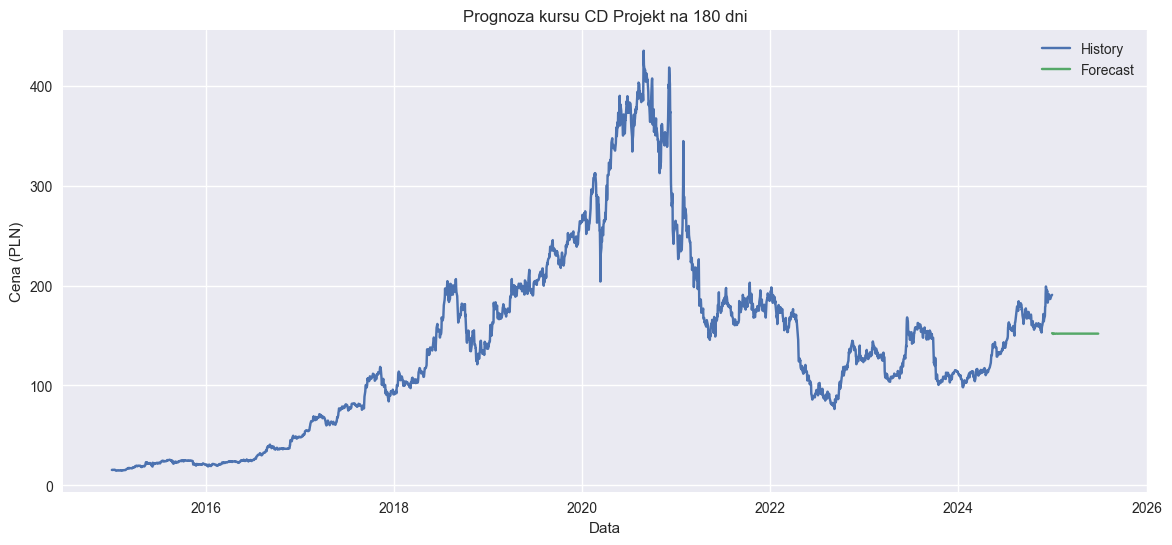

In [50]:
future_forecast = model_fit.forecast(steps=180)

plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'], label="History")
plt.plot(pd.date_range(df.index[-1], periods=180, freq='D'),
         future_forecast, label="Forecast")
plt.title("Prognoza kursu CD Projekt na 180 dni")
plt.xlabel("Data")
plt.ylabel("Cena (PLN)")
plt.grid(True)
plt.legend()

save_plot("cdprojekt_forecast_180dni.png")
plt.show()


✔ Wykres zapisany


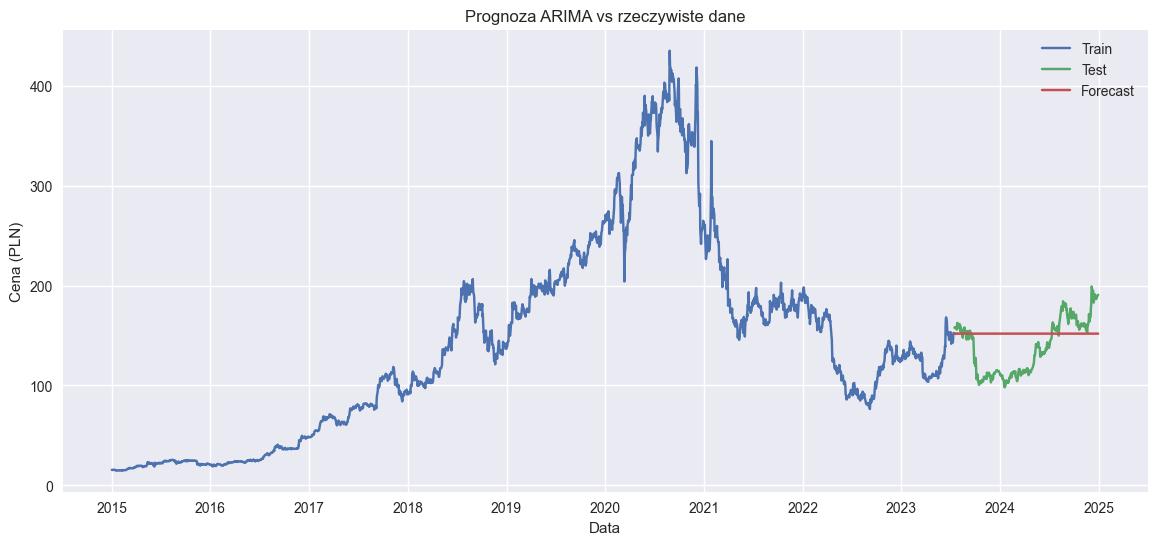

In [49]:
plt.figure(figsize=(14,6))
plt.plot(train.index, train['Close'], label="Train")
plt.plot(test.index, test['Close'], label="Test")
plt.plot(test.index, forecast, label="Forecast")
plt.title("Prognoza ARIMA vs rzeczywiste dane")
plt.xlabel("Data")
plt.ylabel("Cena (PLN)")
plt.grid(True)
plt.legend()

save_plot("cdprojekt_arima_test_vs_real.png")
plt.show()


In [48]:
forecast = model_fit.forecast(steps=len(test))

forecast_df = pd.DataFrame({
    "date": test.index,
    "actual": test['Close'].to_numpy().flatten(),
    "forecast": forecast.to_numpy().flatten()
})

save_forecast(forecast_df, "arima_test_forecast.csv")


c:\Users\wesbl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [46]:
def save_forecast(df, name):
    data_dir = "data"
    os.makedirs(data_dir, exist_ok=True)
    path = os.path.join(data_dir, name)
    df.to_csv(path, index=False)


In [45]:
import os
os.chdir(r"C:\Users\wesbl\OneDrive\Pulpit\cdprojekt-stock-forecast")
os.getcwd()


'C:\\Users\\wesbl\\OneDrive\\Pulpit\\cdprojekt-stock-forecast'

In [35]:
train.tail(), test.head()


(Price            Close
 Ticker          CDR.WA
 Date                  
 2023-07-10  143.923050
 2023-07-11  142.983368
 2023-07-12  148.868866
 2023-07-13  152.380402
 2023-07-14  152.528778,
 Price            Close
 Ticker          CDR.WA
 Date                  
 2023-07-17  157.771317
 2023-07-18  157.721863
 2023-07-19  158.265900
 2023-07-20  158.463730
 2023-07-21  158.018616)

In [34]:
train = df.iloc[:-365]
test = df.iloc[-365:]


✔ Wykres zapisany


<Figure size 1400x1000 with 0 Axes>

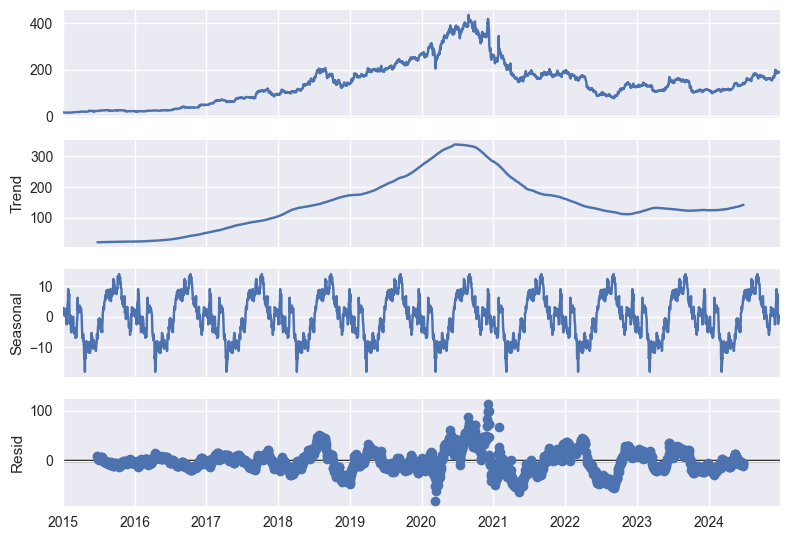

In [40]:
decomp = seasonal_decompose(df['Close'], model='additive', period=252)

plt.figure(figsize=(14,10))
decomp.plot()
plt.tight_layout()

save_plot("cdprojekt_decomposition.png")
plt.show()


In [39]:
import os

def save_plot(filename):
    charts_dir = os.path.join(os.getcwd(), "charts")
    os.makedirs(charts_dir, exist_ok=True)
    path = os.path.join(charts_dir, filename)
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print("✔ Wykres zapisany")


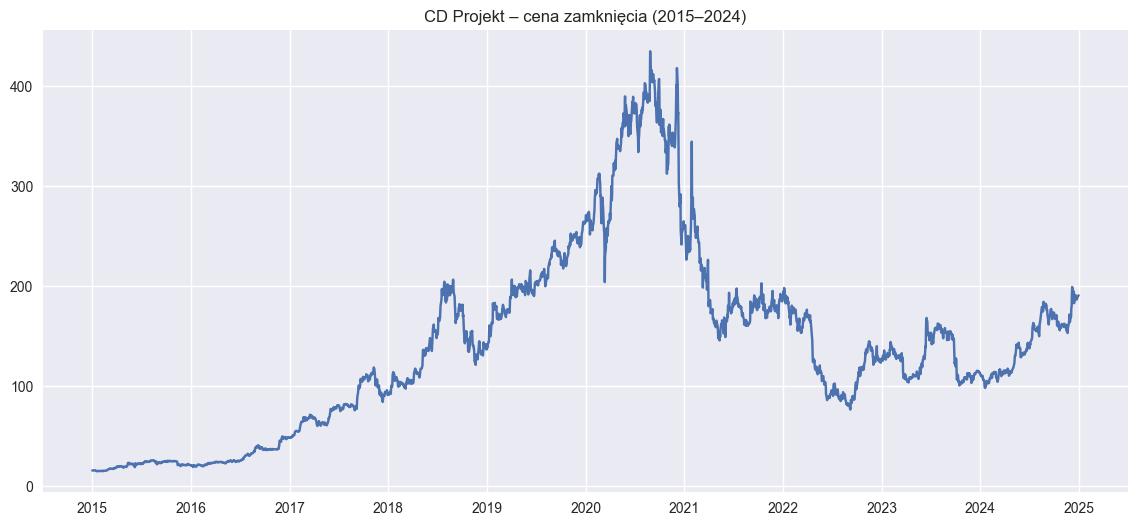

Zapisano


In [37]:
import os

os.makedirs("charts", exist_ok=True)

save_path = "charts/cdprojekt_close_price.png"

plt.figure(figsize=(14,6))
plt.plot(df['Close'])
plt.title("CD Projekt – cena zamknięcia (2015–2024)")
plt.grid(True)

plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print("Zapisano")


In [36]:
import os
os.chdir(r"C:\Users\wesbl\OneDrive\Pulpit\cdprojekt-stock-forecast")
os.getcwd()


'C:\\Users\\wesbl\\OneDrive\\Pulpit\\cdprojekt-stock-forecast'

In [24]:
df.describe()


Price,Close
Ticker,CDR.WA
count,2549.000000
mean,140.576534
std,92.091824
min,14.677927
25%,77.514229
50%,131.539291
75%,182.435638
max,435.130981


In [23]:
df = data.copy()
df = df[['Close']]  
df = df.dropna()

df.head()


Price,Close
Ticker,CDR.WA
Date,
2015-01-01,15.465071
2015-01-02,15.557674
2015-01-05,15.390986
2015-01-06,15.390986
2015-01-07,15.594717


In [22]:
data = yf.download("CDR.WA", start="2015-01-01", end="2024-12-31")
data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CDR.WA,CDR.WA,CDR.WA,CDR.WA,CDR.WA
Date,,,,,
2015-01-01,15.465071,15.465071,15.465071,15.465071,0
2015-01-02,15.557674,15.826230,15.372465,15.826230,39796
2015-01-05,15.390986,15.603978,15.372465,15.603978,36711
2015-01-06,15.390986,15.390986,15.390986,15.390986,0
2015-01-07,15.594717,15.603978,15.279859,15.418767,49044


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

plt.style.use("seaborn-v0_8")


In [20]:
!pip install statsmodels


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 8.6 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.6 MB 10.9 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.6 MB 11.3 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 11.2 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodel


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
